## 머신러닝 예측 실습

### 순서
1. **데이터분석 기획**
2. **데이터 정의 - 수집방법, 컬럼종류**
3. **데이터 준비**
4. **데이터 전처리**
5. **데이터 분석**
6. **머신러닝 모델 학습/예측/평가**
7. **모델 성능향상 방법 찾기**

In [4]:
# Link
# https://archive.ics.uci.edu/dataset/560/seoul%2Bbike%2Bsharing%2Bdemand?utm_source=chatgpt.com

# Additional Variable Information
# Date : year-month-day / 년월일
# Rented Bike count - Count of bikes rented at each hour / 매 시간마다 대여된 자전거 수
# Hour - Hour of he day / 시간대
# Temperature-Temperature in Celsius / 온도(섭씨)
# Humidity - % / 습도
# Windspeed - m/s / 풍속
# Visibility - 10m / 가시거리
# Dew point temperature - Celsius / 이슬점 온도(섭씨)
# Solar radiation - MJ/m2 / 태양 복사열
# Rainfall - mm / 강수량
# Snowfall - cm / 적설량
# Seasons - Winter, Spring, Summer, Autumn / 계절
# Holiday - Holiday/No holiday / 휴일
# Functional Day - NoFunc(Non Functional Hours), Fun(Functional hours) 
#                             - 비기능 / 기능

In [18]:
# # Functioning Day(영업일)이 No이면 애초에 데이터를 수집할 수 없는 것 아닌가?
# # 가시거리가 자전거 대여량에 영향을 미칠까?
# # 이슬점 온도가 영향이 있을까?

# import pandas as pd

# # df1 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1712.csv')
# # df2 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1801.csv')
# # df3 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1802.csv')
# # df4 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1803.csv')
# # df5 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1804.csv')
# # df6 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1805.csv')
# # df7 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1806.csv')
# # df8 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1807.csv')
# # df9 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1808.csv')
# # df10 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1809.csv')
# # df11 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1810.csv')
# # df12 = pd.read_csv('../da_data/SeoulBike/SeoulBikeData_1811.csv')

# # pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12])

# # -------------------------------------
# # -------------------------------------
# import os
# filelist = os.listdir('../da_data/SeoulBike')

# datafile = []

# for file in filelist:
#     if file.endswith(".csv"):
#         datafile.append(file)

# print(datafile)

# dfs = []

# for file in datafile:
#     # print('../da_data/SeoulBike/' + file)
#     filepath = os.path.join('../da_data/SeoulBike', file)
#     dfs.append(pd.read_csv(filepath))

# pd.concat(dfs)


In [29]:
import pandas as pd
import os

folder_path = '../da_data/SeoulBike'

filelist = os.listdir(folder_path)
dfs = []

for file in filelist:
    if file.endswith(".csv"):
        filepath = os.path.join(folder_path, file)
        dfs.append(pd.read_csv(filepath))

bike = pd.concat(dfs, ignore_index=True)

bike.head()

# NULL이 아닌 데이터가 8760개이지만,
# 이상치 또는 결측치가 있을 수 있기 때문에 확인 필요
# .fillna()로 채웠을 수도 있기 때문
bike.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(C)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [35]:
# 평균이 커지면 표준편차도 같이 커진다.
# Rented Bike Count의 중앙값(50%)이 평균(mean)보다 작음 => 왜도 > 0, 오른쪽으로 꼬리가 긴 상태

# 데이터 정의, 데이터 준비하는 과정이 가장 오래 걸림.
# df.describe()는 기본적으로는 숫자형 변수만 보여줌.
bike.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [41]:
# df['컬럼'].value_counts() : 그 컬럼의 각 값 개수를 보여줌.
# 한 시간 기준을 하루 기준으로 바꾸기 위해서 24로 나눔.
# -> 비공휴일 347일, 공휴일 18일
bike['Holiday'].value_counts() / 24

Holiday
No Holiday    347.0
Holiday        18.0
Name: count, dtype: float64

In [46]:
bike['Seasons'].value_counts()

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

In [47]:
bike['Functioning Day'].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [52]:
bike[bike['Functioning Day'] == 'No']['Date'].unique()

<StringArray>
['2018-04-11', '2018-05-10', '2018-09-18', '2018-09-19', '2018-09-28',
 '2018-09-30', '2018-10-02', '2018-10-04', '2018-10-06', '2018-10-09',
 '2018-11-03', '2018-11-06', '2018-11-09']
Length: 13, dtype: str

In [55]:
# 이상값 확인하기
# 불가능하거나 이상한 경우의 수 확인하기

# No이면서 rent 0이 아닌 경우
bike[(bike['Functioning Day'] == 'No') & (bike['Rented Bike Count'] > 0)]
# Yes인데 rent 0인 경우
bike[(bike['Functioning Day'] == 'Yes') & (bike['Rented Bike Count'] == 0)]


,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day


In [56]:
# 강우량과 적설량이 같이 존재하는 경우
bike[(bike['Rainfall(mm)'] != 0) & (bike['Snowfall (cm)'] !=0)]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
120,2017-12-06,145,0,-2.8,77,0.0,331,-6.2,0.00,0.1,0.1,Winter,No Holiday,Yes
123,2017-12-06,78,3,-3.2,78,0.0,1808,-6.4,0.00,0.2,0.4,Winter,No Holiday,Yes
138,2017-12-06,204,18,1.7,90,1.0,66,0.2,0.00,0.3,0.3,Winter,No Holiday,Yes
141,2017-12-06,165,21,1.1,92,0.5,235,0.0,0.00,0.7,1.0,Winter,No Holiday,Yes
222,2017-12-10,9,6,-0.5,90,0.9,91,-1.9,0.00,2.5,2.7,Winter,No Holiday,Yes
225,2017-12-10,31,9,0.2,90,1.0,305,-1.2,0.00,1.6,4.3,Winter,No Holiday,Yes
411,2017-12-18,32,3,-5.3,76,1.0,767,-8.8,0.00,0.3,0.5,Winter,No Holiday,Yes
414,2017-12-18,45,6,-5.2,85,0.9,271,-7.3,0.00,0.4,1.3,Winter,No Holiday,Yes
417,2017-12-18,52,9,-4.3,89,1.0,59,-5.8,0.00,1.6,4.0,Winter,No Holiday,Yes
420,2017-12-18,62,12,-1.8,83,1.2,351,-4.3,0.09,1.1,5.1,Winter,No Holiday,Yes


In [63]:
# 데이터 전처리 단계

# 1. 날짜 변환 (str -> date)
bike['Date'] = pd.to_datetime(bike['Date'])

In [73]:
# 2. 요일 가져오기
bike['Date'].dt.day_of_week.unique()

array([4, 5, 6, 0, 1, 2, 3], dtype=int32)

In [92]:
# Week 컬럼(독립변수) 생성
bike['Week'] = bike['Date'].dt.day_name()
bike['Date'].dt.quarter

0       4
1       4
2       4
3       4
4       4
       ..
8755    4
8756    4
8757    4
8758    4
8759    4
Name: Date, Length: 8760, dtype: int32

In [83]:
bike['Week'].unique()

<StringArray>
['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Length: 7, dtype: str

In [82]:
bike['Holiday'].unique()

<StringArray>
['No Holiday', 'Holiday']
Length: 2, dtype: str

In [ ]:
# 주말 조건
bike['Week'].isin('Saturday', 'Sunday')
# 평일 조건
bike['Week'].notin('Saturday', 'Sunday')

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
# 쉬는날 확인 함수
# 주말(토요일이거나 일요일이거나), 휴일이거나
def check_day(row):
    if ((row['Week'] in ['Saturday', 'Sunday']) or row['Holiday'] == 'Holiday'):
        return 'Yes'
    else:
        return 'No'

bike.apply(check_day, axis = 1)
bike.head()

bike['Day off'] = bike.apply(check_day, axis=1)

# 존재 컬럼 삭제
# bike.drop(labels=['Week', 'Holiday'])

<Axes: xlabel='Date', ylabel='Rented Bike Count'>

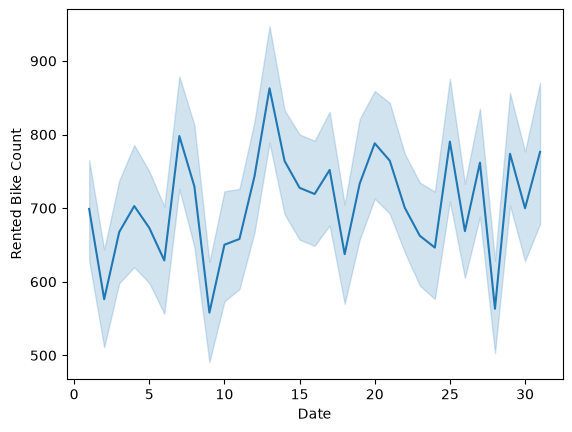

In [97]:
import seaborn as sns

sns.lineplot(x = bike['Date'].dt.day, y = bike['Rented Bike Count'], errorbar=('ci', 95), estimator='mean')

# EDA 끝

In [98]:
# 데이터 분석
# 종속변수 독립변수 중점으로 분석
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Week', 'Day off'],
      dtype='str')

In [ ]:
# 중요한 독립변수라고 생각하는 것
# Hour, Temperature(C), Wind speed (m/s), Visibility (10m), Snowfall (cm), Seasons, Day off

<Axes: xlabel='Week', ylabel='Rented Bike Count'>

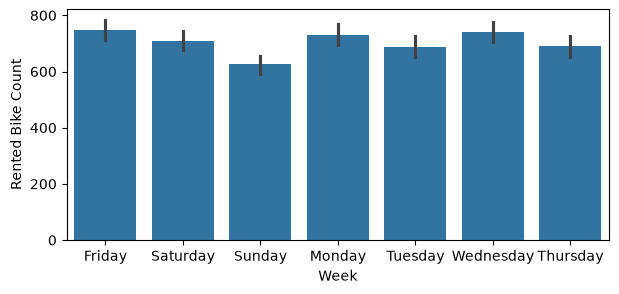

In [109]:
import matplotlib.pyplot as plt

bike['Day off'].value_counts()/24

# sns.barplot(x = 'Day off', y = 'Rented Bike Count', data=bike)
# 평일과 휴일 간의 차이가 잘 보이지 않음.

# sns.barplot(x = 'Holiday', y = 'Rented Bike Count', data=bike)
# 'Day off' 컬럼보다는 차이가 뚜렷하게 드러남.

plt.figure(figsize = (7, 3))
sns.barplot(x = 'Week', y = 'Rented Bike Count', data = bike)

In [ ]:
# df.corr() : 변수 간의 상관관계 출력 함수
bike.corr(numeric_only=True)

# 확인 결과 
# Temperature과 Dew point temperature 간의 다중공선성 발견 (0.912798)

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.410257,0.538558,-0.199780,0.121108,0.199280,0.379788,0.261837,-0.123074,-0.141804
Hour,0.410257,1.000000,0.124114,-0.241644,0.285197,0.098753,0.003054,0.145131,0.008715,-0.021516
Temperature(C),0.538558,0.124114,1.000000,0.159371,-0.036252,0.034794,0.912798,0.353505,0.050282,-0.218405
Humidity(%),-0.199780,-0.241644,0.159371,1.000000,-0.336683,-0.543090,0.536894,-0.461919,0.236397,0.108183
Wind speed (m/s),0.121108,0.285197,-0.036252,-0.336683,1.000000,0.171507,-0.176486,0.332274,-0.019674,-0.003554
Visibility (10m),0.199280,0.098753,0.034794,-0.543090,0.171507,1.000000,-0.176630,0.149738,-0.167629,-0.121695
Dew point temperature(C),0.379788,0.003054,0.912798,0.536894,-0.176486,-0.176630,1.000000,0.094381,0.125597,-0.150887
Solar Radiation (MJ/m2),0.261837,0.145131,0.353505,-0.461919,0.332274,0.149738,0.094381,1.000000,-0.074290,-0.072301
Rainfall(mm),-0.123074,0.008715,0.050282,0.236397,-0.019674,-0.167629,0.125597,-0.074290,1.000000,0.008500
Snowfall (cm),-0.141804,-0.021516,-0.218405,0.108183,-0.003554,-0.121695,-0.150887,-0.072301,0.008500,1.000000


In [ ]:
# 분석 이어서
# 삭제 : 날짜, 이슬점, Functioning Day, rent값이 0인 데이터, Holiday, week
# one-hot, scaler 진행
# 일반화 검증
# 모델 선택(linear, ridge, randomforest)
# 학습/예측/평가
# 성능 향상 (gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

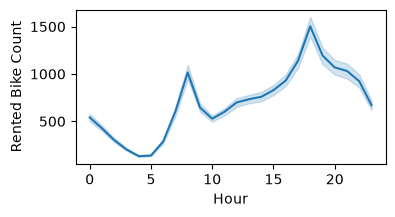

In [ ]:
plt.figure(figsize=(4, 2))
sns.lineplot(x = 'Hour', y='Rented Bike Count', data=bike)
# 출근과 퇴근 시간대에 렌트율이 피크를 찍은 것을 알 수 있음.


In [114]:
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Week', 'Day off'],
      dtype='str')

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

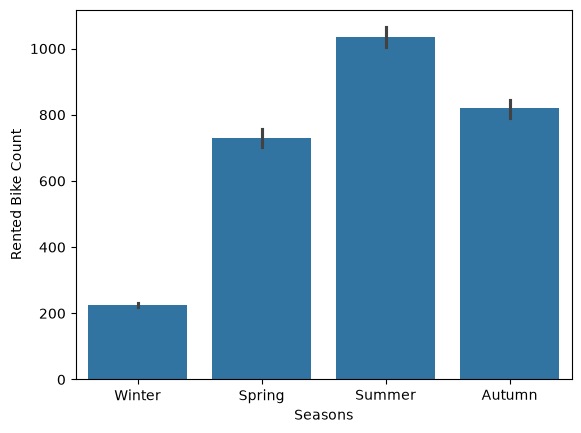

In [116]:
# 겨울에는 유의미하게 렌트율이 낮고, 여름에는 가장 높음.
# 봄과 가을은 비슷함.
sns.barplot(x = 'Seasons', y = 'Rented Bike Count', data=bike)

In [125]:
# 삭제 : 날짜, 이슬점, Functioning Day, rent값이 0인 데이터, Holiday, week

# 종속변수인 Rented Bike Count를 삭제하는 이유 : 

bike = bike[bike['Rented Bike Count'] > 0]

# 독립변수 컬럼들
X = bike.drop(['Date', 'Dew point temperature(C)', 'Functioning Day', 'Holiday', 'Week', 'Rented Bike Count'], axis=1)

# 종속변수 컬럼
# todo : Y값 스케일링 해보기
y = bike['Rented Bike Count']

In [126]:
bike

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Week,Day off
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,No
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,No
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,No
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,No
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,Friday,No
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,Friday,No
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,Friday,No
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,Friday,No


# 데이터 전처리(OneHot, Scaler)

In [140]:
# OneHot, Scaler

from sklearn.preprocessing import OneHotEncoder, StandardScaler

# OneHot 인코딩 완료
oh_enc = OneHotEncoder(sparse_output = False)
oh_res = oh_enc.fit_transform(X[['Hour', 'Seasons', 'Day off']])
oh_X = pd.DataFrame(oh_res, columns = oh_enc.get_feature_names_out())

# feature scaling(StandardScaler)
# 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업
st_scaler = StandardScaler()
num_col = ['Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
sc_res = st_scaler.fit_transform(X[num_col])
sc_X = pd.DataFrame(sc_res, columns = num_col)

X_scaled = pd.concat([sc_X, oh_X], axis=1)

In [148]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor


# 독립변수 데이터를 섞기
X_rand = X_scaled.sample(frac = 1, random_state = 0)
y_rand = y.sample(frac = 1, random_state = 0)

# 의사결정나무(회귀용) 선언
dt_reg = DecisionTreeRegressor()

# 의사결정나무 모델, 스케일링이 끝난 독립변수들(y), 교차검증기준, 교차검증 횟수로 검증
cross_val_score(dt_reg, X_rand, y_rand, scoring = 'neg_mean_squared_error', cv = 5)

array([-73019.88954519, -72241.42941524, -73078.95747194, -70313.88600118,
       -73307.5280567 ])

# 모델 선택(linear, ridge, randomforest)

In [150]:
# 모델 선택(linear, ridge, randomforest)

from sklearn.model_selection import train_test_split

# 모델에 학습시키기 위해 데이터 분할
X_train, X_test, y_train, y_test, = train_test_split(X_scaled, y, test_size = 0.2, random_state = 0)
print(X_train.shape, X_test.shape, y_train.shape)

(6772, 37) (1693, 37) (6772,)


In [ ]:
# 모델 선택 후 학습 / 예측 / 평가 1
# 선형회귀 모델 사용
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)
# 실제값(y_test)을 예측값보다 먼저 넣어야 함.
# 거의 대부분의 평가 지표 함수가 실제값, 예측값 순으로 작동

# RMSE와 결정계수(R^2) 출력
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

378.58069260427027
0.6353286302424679


In [157]:
# 모델 선택 후 학습 / 예측 / 평가 2
# Ridge로 규제 건 경우
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score

ridge = Ridge(alpha = 0.1)
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

# RMSE가 근소 감소, 결정계수가 근소 증가
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

378.57177010860147
0.6353458193936199


In [ ]:
# 모델 선택 후 학습 / 예측 / 평가 3
# 랜덤 포레스트 사용
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
pred = rf_reg.predict(X_test)
# 실제값(y_test)을 예측값보다 먼저 넣어야 함.
# 거의 대부분의 평가 지표 함수가 실제값, 예측값 순으로 작동
print(root_mean_squared_error(y_test, pred))
 
# 모델을 바꿨더니(linear -> ridge -> RandomForest) 
# ridge로 규제를 건 것보다 훨씬 개선됨.
print(r2_score(y_test, pred))

207.5475083624615
0.8903976683207007


In [ ]:
# 성능향상(gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

# 하이퍼 파라미터 설정
from sklearn.model_selection import GridSearchCV

# 랜덤포레스트의 각 트리의 제한값 설정
parameters = {'n_estimators' : [],
               'max_depth' : [], 
               'min_samples_split' : [],
               'min_samples_leaf' : [3]}
grid = GridSearchCV(rf_reg, param_grid = parameters, scoring = 'neg_mean_root_squared_error', cv = 5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_root_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalue